# 4. Stats

Following the analysis for the microbiome in each subject as a whole we will perform similar research on each genus of the microbiome separately. This was decided because the results on the microbiome as a whole did not seem significantly different between the categories (gender and diagnosis).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

meta = pd.read_csv("../data/processed/metadata_final.tsv", sep="\t", index_col="Sample")
genera_clr = pd.read_csv("../data/processed/genera_clr.tsv", sep="\t", index_col=0)

# Align just to be safe
meta = meta.loc[genera_clr.index]

print("Metadata shape:", meta.shape)
print("Genera CLR shape:", genera_clr.shape)
print("Gender counts:\n", meta["Gender"].value_counts())

Metadata shape: (105, 23)
Genera CLR shape: (105, 2761)
Gender counts:
 Gender
Male      53
Female    52
Name: count, dtype: int64


### Step 1: Are specific bacterial genera differently abundant between male and female participants?

In this cell we need to compare the male and female for each genus and extract the possible significant genera.

In [3]:
from scipy.stats import mannwhitneyu

# Use normalized (pre-CLR) data for Mann-Whitney
meta_base = pd.read_csv("../data/processed/metadata_baseline.tsv", sep="\t", index_col="Sample")
genera_base = pd.read_csv("../data/processed/genera_baseline.tsv", sep="\t", index_col=0)

# Reapply filtering and normalization
prevalence = (genera_base > 0).mean()
genera_filtered = genera_base.loc[:, prevalence >= 0.10]
genera_norm = genera_filtered.div(genera_filtered.sum(axis=1), axis=0)

# Align with metadata
genera_norm = genera_norm.loc[meta_base.index]

male_samples = meta_base[meta_base["Gender"] == "Male"].index
female_samples = meta_base[meta_base["Gender"] == "Female"].index

male_data = genera_norm.loc[male_samples]
female_data = genera_norm.loc[female_samples]

n_male = len(male_samples)
n_female = len(female_samples)
print(f"Male samples: {n_male}")
print(f"Female samples: {n_female}")

results = []
for genus in genera_norm.columns:
    male_vals = male_data[genus].values
    female_vals = female_data[genus].values
    
    stat, p = mannwhitneyu(male_vals, female_vals, alternative="two-sided")
    
    # Rank-biserial correlation as effect size
    # ranges from -1 (always higher in females) to +1 (always higher in males)
    rbc = 1 - (2 * stat) / (n_male * n_female)
    
    # Log fold change (mean male / mean female)
    mean_male = male_vals.mean()
    mean_female = female_vals.mean()
    lfc = np.log2((mean_male + 1e-9) / (mean_female + 1e-9))
    
    results.append({
        "genus": genus,
        "p_value": p,
        "rank_biserial": rbc,      # effect size: + = higher in males
        "log2_fold_change": lfc,   # + = higher in males
        "mean_male": mean_male,
        "mean_female": mean_female
    })

results_df = pd.DataFrame(results)
print(f"\nTested {len(results_df)} genera")
print(f"Genera with p<0.05 (before correction): {(results_df['p_value'] < 0.05).sum()}")

Male samples: 53
Female samples: 52

Tested 2761 genera
Genera with p<0.05 (before correction): 131


## Filter false positives

Some genera with raw p<0.05 are expected to be false positives. We use FDR (false discovery rate) to get a more trustworthy list.

In [6]:
from statsmodels.stats.multitest import multipletests

reject, p_adjusted, _, _ = multipletests(results_df["p_value"], method="fdr_bh")
results_df["p_adjusted"] = p_adjusted
results_df["significant"] = reject

print("=== After FDR correction ===")
print(f"Significant genera (FDR < 0.05): {results_df['significant'].sum()}")
print(f"\nTop 10 by raw p-value:")
print(results_df.sort_values("p_value").head(10)[
    ["genus", "p_value", "p_adjusted", "rank_biserial", "log2_fold_change", "significant"]
].round(4).to_string())

=== After FDR correction ===
Significant genera (FDR < 0.05): 0

Top 10 by raw p-value:
                                                                                                               genus  p_value  p_adjusted  rank_biserial  log2_fold_change  significant
1183                    d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UMGS1202   0.0015      0.9373         0.3592           -1.4578        False
2304  d__Bacteria;p__Desulfobacterota;c__Desulfobacteria;o__Desulfobacterales;f__Desulfobacteraceae;g__Desulfobacter   0.0021      0.9373        -0.2293            3.6466        False
1186               d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Acetivibrionales;f__Acetivibrionaceae;g__Acetivibrio   0.0026      0.9373        -0.2656            1.9534        False
797                  d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Chitinophagales;f__Chitinophagaceae;g__Flavitalea   0.0032      0.9373         0.2569           -2.0428      

## Problem: No genus survives the FDR correction --> Possible solutions:

* Strategy 1: Include more bacteria by increasing the threshold for the presence in the subjects.
* Strategy 2: Test the gender differences only in Crohn's disease (CD) and check if it is associated with microbiome differences.

In [7]:
# Strategy 1: Reduce tests by increasing prevalence threshold
prevalence = (genera_base > 0).mean()
genera_strict = genera_base.loc[:, prevalence >= 0.20]
genera_strict_norm = genera_strict.div(genera_strict.sum(axis=1), axis=0)
genera_strict_norm = genera_strict_norm.loc[meta_base.index]

print(f"Genera at 10% prevalence: {genera_norm.shape[1]}")
print(f"Genera at 20% prevalence: {genera_strict_norm.shape[1]}")

# Rerun tests on stricter filtered set
results_strict = []
for genus in genera_strict_norm.columns:
    male_vals = genera_strict_norm.loc[male_samples, genus].values
    female_vals = genera_strict_norm.loc[female_samples, genus].values
    stat, p = mannwhitneyu(male_vals, female_vals, alternative="two-sided")
    rbc = 1 - (2 * stat) / (n_male * n_female)
    lfc = np.log2((male_vals.mean() + 1e-9) / (female_vals.mean() + 1e-9))
    results_strict.append({
        "genus": genus, "p_value": p,
        "rank_biserial": rbc, "log2_fold_change": lfc
    })

results_strict_df = pd.DataFrame(results_strict)
reject_s, p_adj_s, _, _ = multipletests(results_strict_df["p_value"], method="fdr_bh")
results_strict_df["p_adjusted"] = p_adj_s
results_strict_df["significant"] = reject_s

print(f"\nSignificant genera at 20% prevalence (FDR<0.05): {results_strict_df['significant'].sum()}")
print(f"Genera with raw p<0.05: {(results_strict_df['p_value'] < 0.05).sum()}")

Genera at 10% prevalence: 2761
Genera at 20% prevalence: 2007

Significant genera at 20% prevalence (FDR<0.05): 0
Genera with raw p<0.05: 100


In [8]:
# Strategy 2: Test within CD patients only (largest group, more power)
cd_samples = meta_base[meta_base["Study.Group"] == "CD"].index
cd_male = meta_base.loc[cd_samples][meta_base.loc[cd_samples]["Gender"] == "Male"].index
cd_female = meta_base.loc[cd_samples][meta_base.loc[cd_samples]["Gender"] == "Female"].index

print(f"CD males: {len(cd_male)}, CD females: {len(cd_female)}")

results_cd = []
for genus in genera_strict_norm.columns:
    male_vals = genera_strict_norm.loc[cd_male, genus].values
    female_vals = genera_strict_norm.loc[cd_female, genus].values
    if len(male_vals) < 3 or len(female_vals) < 3:
        continue
    stat, p = mannwhitneyu(male_vals, female_vals, alternative="two-sided")
    rbc = 1 - (2 * stat) / (len(cd_male) * len(cd_female))
    lfc = np.log2((male_vals.mean() + 1e-9) / (female_vals.mean() + 1e-9))
    results_cd.append({
        "genus": genus, "p_value": p,
        "rank_biserial": rbc, "log2_fold_change": lfc
    })

results_cd_df = pd.DataFrame(results_cd)
reject_cd, p_adj_cd, _, _ = multipletests(results_cd_df["p_value"], method="fdr_bh")
results_cd_df["p_adjusted"] = p_adj_cd
results_cd_df["significant"] = reject_cd

print(f"Significant genera in CD only (FDR<0.05): {results_cd_df['significant'].sum()}")
print(f"Genera with raw p<0.05 in CD: {(results_cd_df['p_value'] < 0.05).sum()}")
print(f"\nTop 5 in CD:")
print(results_cd_df.sort_values("p_value").head(5)[
    ["genus","p_value","p_adjusted","rank_biserial","log2_fold_change"]
].round(4).to_string())

CD males: 26, CD females: 23
Significant genera in CD only (FDR<0.05): 0
Genera with raw p<0.05 in CD: 81

Top 5 in CD:
                                                                                                            genus  p_value  p_adjusted  rank_biserial  log2_fold_change
1425      d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Dermatophilaceae;g__Tetrasphaera   0.0021      0.9859        -0.4582            1.9578
699              d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Acutalibacteraceae;g__Avimonas_A   0.0037      0.9859         0.4381           -2.0939
292                d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Acutalibacteraceae;g__UMGS1264   0.0057      0.9859         0.4632           -0.5651
1480  d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Sphaerochaetales;f__Sphaerochaetaceae;g__Ornithospirochaeta   0.0062      0.9859         0.4431           -1.3942
675               d__Bacteria;p__Firmicu

A p-value tells us whether a difference may exist in our data. RBC (Rank-Biserial Corellation) can tell us how large and directional that difference is. From the next cell we select some candidate genera using both p-value and RBC

In [ ]:
# Select candidate genera for ML using raw p<0.05 + meaningful effect size

PVAL_THRESHOLD = 0.05
EFFECT_THRESHOLD = 0.20  # |rank-biserial| > 0.20 means at least moderate effect

candidates = results_strict_df[
    (results_strict_df["p_value"] < PVAL_THRESHOLD) &
    (results_strict_df["rank_biserial"].abs() > EFFECT_THRESHOLD)
].sort_values("p_value")

print(f"Candidate genera (p<0.05 AND |RBC|>0.20): {len(candidates)}")
print(f"  Higher in males (RBC>0):  {(candidates['rank_biserial'] > 0).sum()}")
print(f"  Higher in females (RBC<0): {(candidates['rank_biserial'] < 0).sum()}")
print(f"\nTop 15 candidates:")
print(candidates.head(15)[
    ["genus","p_value","rank_biserial","log2_fold_change"]
].round(4).to_string())

# Save candidates for ML notebook
candidates.to_csv("../data/processed/candidate_genera.csv", index=False)

# Also save the full results
results_strict_df.to_csv("../data/processed/stats_results_gender.csv", index=False)

print("\nSaved candidate genera to data/processed/candidate_genera.csv")

Candidate genera (p<0.05 AND |RBC|>0.20): 82
  Higher in males (RBC>0):  26
  Higher in females (RBC<0): 56

Top 15 candidates:
                                                                                                             genus  p_value  rank_biserial  log2_fold_change
1054                  d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UMGS1202   0.0016         0.3585           -1.4567
1057             d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Acetivibrionales;f__Acetivibrionaceae;g__Acetivibrio   0.0026        -0.2656            1.9535
714                d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Chitinophagales;f__Chitinophagaceae;g__Flavitalea   0.0032         0.2569           -2.0420
1473                     d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__UBA2942   0.0038        -0.3200            0.9347
641               d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Treponematales;f__Tre

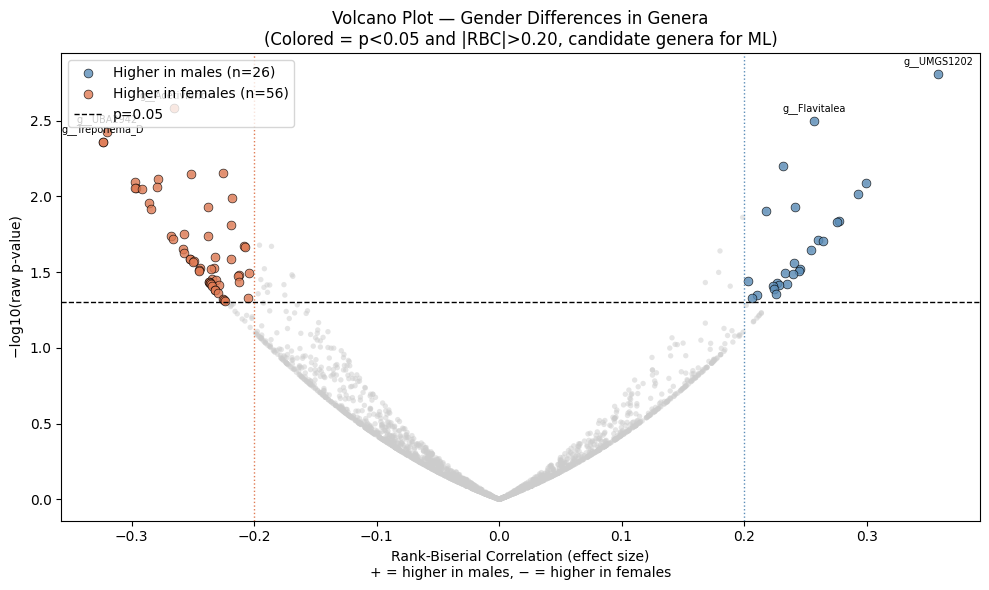

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# All genera in grey
ax.scatter(results_strict_df["rank_biserial"],
           -np.log10(results_strict_df["p_value"]),
           c="#cccccc", alpha=0.5, edgecolors="none", s=15)

# Candidates colored by direction
male_higher = candidates[candidates["rank_biserial"] > 0]
female_higher = candidates[candidates["rank_biserial"] < 0]

ax.scatter(male_higher["rank_biserial"],
           -np.log10(male_higher["p_value"]),
           c="#5b8db8", alpha=0.8, edgecolors="black",
           linewidths=0.5, s=40, label=f"Higher in males (n={len(male_higher)})")

ax.scatter(female_higher["rank_biserial"],
           -np.log10(female_higher["p_value"]),
           c="#e07b54", alpha=0.8, edgecolors="black",
           linewidths=0.5, s=40, label=f"Higher in females (n={len(female_higher)})")

# Threshold lines
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="p=0.05")
ax.axvline(0.20, color="#5b8db8", linestyle=":", linewidth=1)
ax.axvline(-0.20, color="#e07b54", linestyle=":", linewidth=1)

# Annotate top 5 by p-value
for _, row in candidates.head(5).iterrows():
    short = row["genus"].split(";")[-1].strip()
    ax.annotate(short,
                (row["rank_biserial"], -np.log10(row["p_value"])),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.set_title("Volcano Plot — Gender Differences in Genera\n(Colored = p<0.05 and |RBC|>0.20, candidate genera for ML)")
ax.set_xlabel("Rank-Biserial Correlation (effect size)\n+ = higher in males, − = higher in females")
ax.set_ylabel("−log10(raw p-value)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("../results/figures/11_volcano_gender.png", dpi=150)
plt.show()

## Summary & Pivot

Gender-based differential abundance analysis yielded no FDR-significant 
genera (0/2761), consistent with the non-significant diversity results 
in notebook 03. This is likely driven by limited statistical power 
(105 subjects vs 2761 features).

The 82 exploratory candidates (p<0.05, |RBC|>0.20) are saved for 
cross-reference in the XAI notebook (06), but the primary analysis 
pivots to diagnosis classification (UC vs nonIBD, CD vs nonIBD) 
in notebook 05, where the biological signal is expected to be stronger.